In [1]:
import skimage as sk
import matplotlib.pyplot as plt
import numpy as np
import os
import napari
from glob import glob

In [ ]:
gradient = sk.io.imread('/home/gkristin/Pictures/LUMENA_Gradient.jpg')
text_options = sorted(glob('/home/gkristin/Pictures/LUMENA_*.png'))


In [ ]:
names = list(map(os.path.basename,text_options))
text_imgs = list(map(sk.io.imread,text_options))
text_imgs_binary = [sk.color.rgb2gray(sk.color.rgba2rgb(img)) for img in text_imgs]
inverted_masks = [(1-img) for img in text_imgs_binary]

In [ ]:
resized_masks = [sk.transform.resize(mask,gradient.shape) for mask in inverted_masks]
masked_gradients = [(mask*gradient) for mask in resized_masks]

In [ ]:
np.max(masked_gradients[0])

In [ ]:
save_path = '/home/gkristin/Pictures/'
for masked, name in zip(masked_gradients,names):
    img_int = np.array(masked, dtype=np.int8)
    sk.io.imsave(os.path.join(save_path,f'Logo_{name[:-4]}.tif'),img_int)

In [ ]:
logo_binary = sk.color.rgb2gray(sk.color.rgba2rgb(logo))
logo_binary.shape

In [ ]:
viewer = napari.Viewer()

In [ ]:
logo_binary_mask = (1-logo_binary)
viewer.add_image(logo_binary_mask)

In [ ]:
logo_mask = sk.transform.resize(logo_binary_mask,gradient.shape)

In [ ]:
masked_gradient = logo_mask * gradient
viewer.add_image(masked_gradient)

In [ ]:
save_path = '/home/gkristin/Pictures/'
sk.io.imsave(os.path.join(save_path,'LUMENA_Logo_Latin-Modern-Sans-Quotation.tif'),masked_gradient,check_contrast=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-128..127].


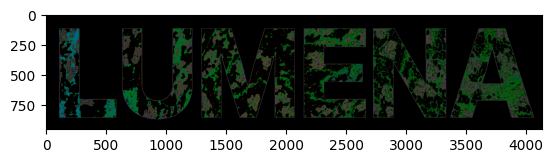

In [10]:
new_logo = sk.io.imread('/home/gkristin/Pictures/Logo_Options/Logo_LUMENA_InterDisplayExtraBold.tif')
plt.imshow(new_logo[750:1700,:])



In [11]:
cropped_logo = new_logo[750:1700,:]
cropped_logo.dtype

dtype('int8')

In [12]:
sk.io.imsave('/home/gkristin/Pictures/Logo_Options/Logo_LUMENA.tif',cropped_logo)